# Cortical TRF analysis 3: does SI-GEVD denoising actually help?

Three sub-questions, each comparing the plain `raw='ica'` pipeline against
`raw='ica-sigevd'` (see `experiment_sigevd.py`), across every condition
with real two-talker or single-talker EEG - clean speech, diotic,
dichotic-left, dichotic-right, binaural:

1. **Neural tracking (Pearson r)** - three separate raw-vs-SI-GEVD
   comparisons per condition:
   - the full model's own `r` (not a difference - each pipeline's own
     overall fit quality);
   - onset's unique contribution (`compute_unique_contribution`, reused
     unmodified from `cortical_analysis_2.ipynb`: full model's `r` minus
     the same model with onset removed);
   - envelope's unique contribution, same idea.
2. **Neural tracking (proportion of variance explained)** - identical to
   (1), `metric='ev'`.
3. **Envelope decoding accuracy** - a stimulus-reconstruction backward
   model (`eelbrain.boosting`/`convolve`/`correlation_coefficient`, per
   eelbrain's own decoding-tutorial recipe, not the `sigevd.trf_estim`
   -based classifier an earlier version of this notebook used): per
   subject, train a decoder on every trial but the last, use it to
   reconstruct the last trial's (attended) envelope from EEG, and score by
   correlation with the real envelope. Runs for every condition, including
   clean speech - there's no attended-vs-ignored classification here, just
   envelope-reconstruction accuracy.

Every comparison uses the same bar+swarm plot (mean +/- SEM, and one dot
per subject) for raw vs SI-GEVD directly, plus a paired Wilcoxon
signed-rank test (`sigevd_eval.paired_wilcoxon`) - not eelbrain's own
cluster-permutation test, since a single `e.load_model_test()` call can
only test within one raw pipeline at a time; there's no eelbrain result
object spanning both `'ica'` and `'ica-sigevd'` to draw one from.
Threshold: p < 0.025 (Bonferroni correction for 2 comparisons, as
specified).

**This notebook has never been fully run.** Expect live-debugging rounds,
same as `cortical_analysis_2.ipynb`'s own SI-GEVD integration - sub-
question 3's decoder in particular is new and untested against eelbrain or
this project's real dataset.

In [ ]:
from eelbrain import *
from experiment import FIGURES_DIR, topomap_with_colorbar, e as e_raw
from experiment_sigevd import e as e_sigevd, load_envelope_decoder_data
from sigevd_eval import paired_wilcoxon
import matplotlib.pyplot as plt
import numpy
import seaborn as sns

# Where to save plots - inside the BIDS dataset's derivatives, same as
# cortical_analysis.ipynb/cortical_analysis_2.ipynb, not somewhere outside
# the dataset.
DST = FIGURES_DIR

## Preprocessing (run once per subject)

Identical to `cortical_analysis_2.ipynb` - both notebooks use the same
preprocessed EEG (`raw='ica'`), so this only does real work the first
time any of the three notebooks is run for a given subject. `'ica-sigevd'`
builds on top of `'ica'` (see `experiment_sigevd.py`) rather than
needing its own separate bad-channels/ICA step, so this only needs to
run against `e_raw`.

In [16]:
MANUAL_BAD_CHANNELS = False
AUTO_BAD_CHANNELS_R = 0.3
REDO_BAD_CHANNELS = True

e_raw.mark_bad_channels(
    'all',
    manual_bad_channels=MANUAL_BAD_CHANNELS, auto_bad_channels_r=AUTO_BAD_CHANNELS_R,
    redo_bad_channels=REDO_BAD_CHANNELS,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. Bad channels marked.


In [17]:
MANUAL_ICA = False
AUTO_ICA_CONFIDENCE = 0.75

e_raw.select_ica_artifacts(
    'all',
    manual_ica=MANUAL_ICA, auto_ica_confidence=AUTO_ICA_CONFIDENCE,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. ICA fit and artifact components selected.


## Shared setup

Everything in this section is reused by every sub-question/condition
below. Mostly identical to `cortical_analysis_2.ipynb`'s own shared setup
(reused verbatim where possible), plus the raw-vs-SI-GEVD comparison
infrastructure this notebook adds.

In [18]:
ATTEND, IGNORE, MIX = '', 'bg~', 'mix~'


def envelope(role=ATTEND):
    return f"{role}gammatone-8"


def onset(role=ATTEND):
    return f"{role}gammatone-on-8"


FULL_CLEAN = f"{envelope(ATTEND)} + {onset(ATTEND)}"
FULL_BASE = f"{envelope(ATTEND)} + {onset(ATTEND)} + {envelope(IGNORE)} + {onset(IGNORE)} + {envelope(MIX)} + {onset(MIX)}"

In [ ]:
PMIN = 0.05
TOPO_ARGS = dict(clip='circle')

### Two pipelines, side by side

Unlike `cortical_analysis_2.ipynb` (which swaps the single global `e`/
`PARAMETERS` in place), this notebook needs *both* pipelines available at
once to compare them - `e_raw`/`PARAMETERS_RAW` (plain `'ica'`) and
`e_sigevd`/`PARAMETERS_SIGEVD` (`'ica-sigevd'`), never reassigned.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


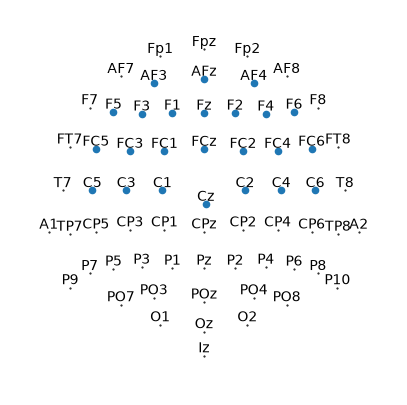

In [20]:
PARAMETERS_RAW = {
    'raw': 'ica',
    'group': 'all',
    'samplingrate': 128,
    'data': 'eeg',
    'tstart': -0.100,
    'tstop': 0.600,
}
PARAMETERS_SIGEVD = {**PARAMETERS_RAW, 'raw': 'ica-sigevd'}

LAG_START_MS = PARAMETERS_RAW['tstart'] * 1e3
LAG_STOP_MS = PARAMETERS_RAW['tstop'] * 1e3
LAM = 0.2  # matches experiment_sigevd.py's own SIGEVD_LAM - the paper's example value, not tuned for this dataset

data = e_raw.load_trfs(1, 'gammatone-8', epoch='clean', **PARAMETERS_RAW)
eeg = data['ev']

ROI = [
    'AF3', 'F1', 'F3', 'F5',
    'FC5', 'FC3', 'FC1',
    'C1', 'C3', 'C5',
    'AF4', 'AFz',
    'Fz', 'F2', 'F4', 'F6',
    'FC6', 'FC4', 'FC2', 'FCz',
    'Cz', 'C2', 'C4', 'C6',
]

p = plot.SensorMap(eeg, mark=ROI)

### Model-comparison helpers

`compute_unique_contribution` is reused unmodified from
`cortical_analysis_2.ipynb` - it reads `e`/`PARAMETERS` from this
module's global scope, so `run_unique_contribution_both_pipelines` below
temporarily points them at one pipeline, calls it, then the other
(nothing else in this notebook reads bare `e`/`PARAMETERS`, so there's
nothing to restore afterward).

In [ ]:
def compute_unique_contribution(full_model, predictor, epoch, metric, roi=ROI):
    "Omission comparison: does `predictor` uniquely improve on `full_model` with it removed?"
    comparison = f"{full_model} @ {predictor}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=PMIN, metric=metric, epoch=epoch, return_data=True)
    diff = table.difference(metric, 'model', 'test', 'baseline', 'subject', data=data)
    diff[f'roi_{metric}'] = diff[metric].mean(sensor=roi)
    return data, diff, result


def run_unique_contribution_both_pipelines(full_model, predictor, epoch, metric):
    "compute_unique_contribution() under both e_raw/PARAMETERS_RAW and e_sigevd/PARAMETERS_SIGEVD - nothing else in this notebook reads bare e/PARAMETERS, so there's nothing to restore afterward"
    global e, PARAMETERS
    e, PARAMETERS = e_raw, PARAMETERS_RAW
    data_raw, diff_raw, _ = compute_unique_contribution(full_model, predictor, epoch, metric)
    e, PARAMETERS = e_sigevd, PARAMETERS_SIGEVD
    data_sigevd, diff_sigevd, _ = compute_unique_contribution(full_model, predictor, epoch, metric)
    return data_raw, diff_raw, data_sigevd, diff_sigevd

### Sub-question 1: neural tracking (Pearson r)

Three raw-vs-SI-GEVD comparisons per condition, each scored by `r`
(correlation between predicted and actual EEG) and shown as a bar+swarm
plot, plus group-averaged topomaps (one for raw, one for SI-GEVD) of
whatever's being compared:

- **Full model** - each pipeline's own overall fit quality (not a
  difference), from `compute_full_model_metric`. One topomap pair (raw,
  SI-GEVD) of the full model's own map.
- **Onset** / **Envelope** - that predictor's unique contribution
  (`compute_unique_contribution`: the full model's `r` minus the same
  model with that predictor removed), for raw and SI-GEVD separately, via
  `run_unique_contribution_both_pipelines`. Three topomap pairs: the
  "test" model (full model, with the predictor), the "baseline" model
  (predictor removed), and "test - baseline" (the unique-contribution map
  itself, before ROI-averaging into the bar+swarm plot below).

In [ ]:
PIPELINE_COLORS = {'Raw': '#6aa84f', 'SI-GEVD': '#3d85c6'}


def plot_bar_swarm_comparison(values_raw, values_sigevd, ylabel, title):
    "Side-by-side comparison, raw vs SI-GEVD: a bar plot (mean +/- SEM) and a per-subject swarm plot, sharing one y-axis label"
    labels = ['Raw'] * len(values_raw) + ['SI-GEVD'] * len(values_sigevd)
    values = numpy.concatenate([values_raw, values_sigevd])

    fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
    sns.barplot(x=labels, y=values, hue=labels, palette=PIPELINE_COLORS, legend=False, errorbar='se', ax=axes[0])
    axes[0].set_ylabel(ylabel)
    sns.swarmplot(x=labels, y=values, hue=labels, palette=PIPELINE_COLORS, legend=False, size=5, ax=axes[1])
    axes[1].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=9)
    fig.tight_layout()
    return fig

In [ ]:
METRIC_YLABEL = {'r': 'Pearson r', 'ev': 'Proportion variance explained'}


def plot_topomap_pair(map_raw, map_sigevd, label, epoch, metric):
    "One group-averaged topomap for raw, one for SI-GEVD"
    pct = metric == 'ev'
    kwargs = dict(pct=pct, condition=epoch, colorbar_side='left', colorbar_label=False, **TOPO_ARGS)
    topomap_with_colorbar(None, map_raw, label=f'{label}: raw', **kwargs)
    topomap_with_colorbar(None, map_sigevd, label=f'{label}: SI-GEVD', **kwargs)


def compute_full_model_metric(pipeline, params, full_model, epoch, metric, roi=ROI):
    "Each pipeline's own full-model fit quality (not a unique-contribution difference) - the per-subject, per-sensor metric NDVar, not yet ROI- or subject-averaged"
    data = pipeline.load_trfs('all', full_model, epoch=epoch, **params)
    return data[metric]


def section_full_model_tracking(full_model, label, epoch, metric):
    metric_raw = compute_full_model_metric(e_raw, PARAMETERS_RAW, full_model, epoch, metric)
    metric_sigevd = compute_full_model_metric(e_sigevd, PARAMETERS_SIGEVD, full_model, epoch, metric)

    plot_topomap_pair(metric_raw.mean('case'), metric_sigevd.mean('case'), f'{label} full model', epoch, metric)

    vals_raw = metric_raw.mean(sensor=ROI).x
    vals_sigevd = metric_sigevd.mean(sensor=ROI).x

    stat, p, sig = paired_wilcoxon(vals_raw, vals_sigevd)
    print(f"{label} ({epoch}), {metric}: raw mean={vals_raw.mean():.4g}, SI-GEVD mean={vals_sigevd.mean():.4g}, Wilcoxon W={stat:.3f}, p={p:.4f}, significant (p<0.025)={sig}")

    return plot_bar_swarm_comparison(vals_raw, vals_sigevd, METRIC_YLABEL[metric], f'{label} ({epoch})')


def section_unique_contribution(full_model, predictor, label, epoch, metric):
    data_raw, diff_raw, data_sigevd, diff_sigevd = run_unique_contribution_both_pipelines(full_model, predictor, epoch, metric)

    test_raw = data_raw.sub(data_raw['model'] == 'test')[metric].mean('case')
    test_sigevd = data_sigevd.sub(data_sigevd['model'] == 'test')[metric].mean('case')
    plot_topomap_pair(test_raw, test_sigevd, f'{label} test', epoch, metric)

    baseline_raw = data_raw.sub(data_raw['model'] == 'baseline')[metric].mean('case')
    baseline_sigevd = data_sigevd.sub(data_sigevd['model'] == 'baseline')[metric].mean('case')
    plot_topomap_pair(baseline_raw, baseline_sigevd, f'{label} baseline', epoch, metric)

    diff_map_raw = diff_raw[metric].mean('case')
    diff_map_sigevd = diff_sigevd[metric].mean('case')
    plot_topomap_pair(diff_map_raw, diff_map_sigevd, f'{label} test-baseline', epoch, metric)

    vals_raw = diff_raw[f'roi_{metric}'].x
    vals_sigevd = diff_sigevd[f'roi_{metric}'].x

    stat, p, sig = paired_wilcoxon(vals_raw, vals_sigevd)
    print(f"{label} unique contribution ({epoch}), {metric}: raw mean={vals_raw.mean():.4g}, SI-GEVD mean={vals_sigevd.mean():.4g}, Wilcoxon W={stat:.3f}, p={p:.4f}, significant (p<0.025)={sig}")

    return plot_bar_swarm_comparison(vals_raw, vals_sigevd, METRIC_YLABEL[metric], f'{label} unique contribution ({epoch})')

### Sub-question 2: neural tracking (proportion of variance explained)

Identical to sub-question 1's three comparisons (full model, onset,
envelope), just `metric='ev'` instead of `'r'`.

### Sub-question 3: envelope decoding accuracy

Per subject: train an envelope decoder (`eelbrain.boosting`, a backward
model predicting the attended stream's broadband envelope from EEG,
`tstart`/`tstop` = -500ms to 0 - eelbrain's own decoding-tutorial recipe)
on every trial but the last, use `eelbrain.convolve` to reconstruct the
last (held-out) trial's envelope from its EEG, and score by
`eelbrain.correlation_coefficient` against the real envelope. Not the
`sigevd.trf_estim`-based attended-vs-ignored classifier an earlier version
of this notebook used - just envelope-reconstruction accuracy, so it runs
for every condition, including clean speech.

In [ ]:
DECODER_TSTART = -0.500  # seconds - backward model: past EEG predicts the current envelope sample
DECODER_TSTOP = 0.
DECODER_PARTITIONS = 5
DECODER_DELTA = 0.05  # larger step size than the forward TRF's boosting - faster training


def compute_envelope_decoding_r(pipeline, params, epoch):
    "Per-subject: fit the envelope decoder on every trial but the last, reconstruct the last trial's envelope, and return its correlation with the real envelope"
    subjects = pipeline.get_field_values('subject')
    values = []
    for subject in subjects:
        data = load_envelope_decoder_data(pipeline, subject, epoch, params['raw'], params['samplingrate'])
        train = data[:-1]
        decoder = boosting('envelope', 'eeg', DECODER_TSTART, DECODER_TSTOP, data=train, partitions=DECODER_PARTITIONS, delta=DECODER_DELTA)
        eeg_test = data[-1, 'eeg'] / decoder.x_scale
        y_pred = convolve(decoder.h, eeg_test)
        r = correlation_coefficient(data[-1, 'envelope'], y_pred)
        values.append(float(r))
    return numpy.array(values)


def section_envelope_decoding(label, epoch):
    r_raw = compute_envelope_decoding_r(e_raw, PARAMETERS_RAW, epoch)
    r_sigevd = compute_envelope_decoding_r(e_sigevd, PARAMETERS_SIGEVD, epoch)

    stat, p, sig = paired_wilcoxon(r_raw, r_sigevd)
    print(f"{label} decoding ({epoch}): raw mean={r_raw.mean():.4g}, SI-GEVD mean={r_sigevd.mean():.4g}, Wilcoxon W={stat:.3f}, p={p:.4f}, significant (p<0.025)={sig}")

    return plot_bar_swarm_comparison(r_raw, r_sigevd, 'Pearson r', f'{label} decoding ({epoch})')

## Clean

### Sub-question 1: neural tracking (Pearson r)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_CLEAN, 'Full model', 'clean', metric='r')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_CLEAN, onset(ATTEND), 'Onset', 'clean', metric='r')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_CLEAN, envelope(ATTEND), 'Envelope', 'clean', metric='r')

### Sub-question 2: neural tracking (proportion of variance explained)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_CLEAN, 'Full model', 'clean', metric='ev')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_CLEAN, onset(ATTEND), 'Onset', 'clean', metric='ev')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_CLEAN, envelope(ATTEND), 'Envelope', 'clean', metric='ev')

### Sub-question 3: envelope decoding accuracy

In [ ]:
p = section_envelope_decoding('Envelope', 'clean')

## Diotic

### Sub-question 1: neural tracking (Pearson r)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'diotic', metric='r')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'diotic', metric='r')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'diotic', metric='r')

### Sub-question 2: neural tracking (proportion of variance explained)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'diotic', metric='ev')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'diotic', metric='ev')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'diotic', metric='ev')

### Sub-question 3: envelope decoding accuracy

In [ ]:
p = section_envelope_decoding('Envelope', 'diotic')

## Dichotic Left

### Sub-question 1: neural tracking (Pearson r)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'dichotic-left', metric='r')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'dichotic-left', metric='r')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'dichotic-left', metric='r')

### Sub-question 2: neural tracking (proportion of variance explained)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'dichotic-left', metric='ev')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'dichotic-left', metric='ev')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'dichotic-left', metric='ev')

### Sub-question 3: envelope decoding accuracy

In [ ]:
p = section_envelope_decoding('Envelope', 'dichotic-left')

## Dichotic Right

### Sub-question 1: neural tracking (Pearson r)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'dichotic-right', metric='r')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'dichotic-right', metric='r')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'dichotic-right', metric='r')

### Sub-question 2: neural tracking (proportion of variance explained)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'dichotic-right', metric='ev')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'dichotic-right', metric='ev')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'dichotic-right', metric='ev')

### Sub-question 3: envelope decoding accuracy

In [ ]:
p = section_envelope_decoding('Envelope', 'dichotic-right')

## Binaural

### Sub-question 1: neural tracking (Pearson r)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'binaural', metric='r')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'binaural', metric='r')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'binaural', metric='r')

### Sub-question 2: neural tracking (proportion of variance explained)

#### Full model

In [ ]:
p = section_full_model_tracking(FULL_BASE, 'Full model', 'binaural', metric='ev')

#### Onset

In [ ]:
p = section_unique_contribution(FULL_BASE, onset(ATTEND), 'Onset', 'binaural', metric='ev')

#### Envelope

In [ ]:
p = section_unique_contribution(FULL_BASE, envelope(ATTEND), 'Envelope', 'binaural', metric='ev')

### Sub-question 3: envelope decoding accuracy

In [ ]:
p = section_envelope_decoding('Envelope', 'binaural')